In [1]:
%load_ext autoreload
%autoreload 2

import os
import random
import numpy as np
import pandas as pd
import sys
import torch
from pathlib import Path
import matplotlib.pyplot as plt

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_dtype(torch.float64)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
if torch.backends.cudnn.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def find_root(current_path, marker="setup.py"):
    current_path = Path(current_path).resolve()
    for parent in [current_path] + list(current_path.parents):
        if (parent / marker).exists():
            return parent
    return current_path

PROJECT_ROOT = find_root(Path.cwd())
DATASETS_DIR = PROJECT_ROOT / "data" / "datasets"
RESULTS_DIR = PROJECT_ROOT / "data" / "results"
ASSETS_DIR = PROJECT_ROOT / "experiments" / "shared" / "assets"

if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from rl_methods.sbeed import (
    MultiParametrizedSBEED,
    DiscreteMDPSpec,
    TabularStateFeatures,
    TabularStateActionFeatures,
    SBEEDEvaluator,
)

print(DEVICE)

cuda


## MDP

In [2]:
states = torch.arange(9, dtype=torch.long)
actions = torch.arange(4, dtype=torch.long)

N = len(states)
A = len(actions)
gamma = 0.9

x_0 = 0
goal_grid = 8

In [3]:
def to_rc(s):
    return divmod(int(s), 3)

def to_s(r, c):
    return r * 3 + c

def next_state(s, a):
    s = int(s)
    a = int(a)

    if s == goal_grid:
        return goal_grid

    r, c = to_rc(s)

    if a == 0:      # Up
        r = max(0, r - 1)
    elif a == 1:    # Down
        r = min(2, r + 1)
    elif a == 2:    # Left
        c = max(0, c - 1)
    elif a == 3:    # Right
        c = min(2, c + 1)

    return to_s(r, c)


### Features

In [4]:
value_features = TabularStateFeatures(n_states=N)
rho_features = TabularStateActionFeatures(n_states=N, n_actions=A)

mdp_spec = DiscreteMDPSpec(
    n_states=N,
    n_actions=A,
    gamma=gamma,
    value_features=value_features,
    rho_features=rho_features,
    x0=x_0,
)

def reward_fn(s, a, sp):
    # Same idea as your old omega: reward 1 at the goal.
    return 1.0 if int(sp) == goal_grid else -0.1

## Solving it

With k = 2 we have the best trade off, but takes much more time:

In [5]:
solver_sbeed = MultiParametrizedSBEED(
    spec=mdp_spec,
    lambda_entropy=0.01,
    eta=0.01,
    lr_value=3e-3,
    lr_rho=1e-2,
    lr_policy=1e-3,
    tau=100000.0,
    max_buffer_size=3000,
    batch_size=256,
    rollout_length=2,
    fisher_damping=1e-2,
    cg_iters=10,
    cg_tol=1e-12,
    seed=SEED,
    device=DEVICE,
)

pi_sbeed = solver_sbeed.run(
    transition_fn=next_state,
    reward_fn=reward_fn,
    episodes=1000,
    collect_per_episode=20,
    updates_per_episode=10,
    initial_collect_steps=50,
    start_state=x_0,
    epsilon=0.1,
    terminal_states={goal_grid},
    log_every=50,
)

episode=50/1000 buffer=1050 objective=0.059192 primal_mse=0.059224 dual_mse=0.003217 theta_grad=4.400e-02 policy_grad=8.893e-02
episode=100/1000 buffer=2050 objective=0.056950 primal_mse=0.056993 dual_mse=0.004231 theta_grad=3.676e-02 policy_grad=9.862e-02
episode=150/1000 buffer=3000 objective=0.052219 primal_mse=0.052278 dual_mse=0.005942 theta_grad=2.742e-02 policy_grad=1.091e-01
episode=200/1000 buffer=3000 objective=0.041561 primal_mse=0.041648 dual_mse=0.008680 theta_grad=2.787e-02 policy_grad=1.017e-01
episode=250/1000 buffer=3000 objective=0.029823 primal_mse=0.029928 dual_mse=0.010436 theta_grad=1.420e-02 policy_grad=8.553e-02
episode=300/1000 buffer=3000 objective=0.022268 primal_mse=0.022381 dual_mse=0.011225 theta_grad=2.725e-02 policy_grad=7.807e-02
episode=350/1000 buffer=3000 objective=0.017166 primal_mse=0.017282 dual_mse=0.011564 theta_grad=2.049e-02 policy_grad=5.957e-02
episode=400/1000 buffer=3000 objective=0.014671 primal_mse=0.014789 dual_mse=0.011790 theta_grad=1

In [6]:
evaluator = SBEEDEvaluator(
    solver_sbeed,
    next_state_fn=next_state,
    reward_fn=reward_fn,
)
evaluator.print_policy()


========== SBEED POLICY ==========

State 0: pi(0|0)=0.013  pi(1|0)=0.486  pi(2|0)=0.013  pi(3|0)=0.487  --> best action: 3
State 1: pi(0|1)=0.006  pi(1|1)=0.706  pi(2|1)=0.000  pi(3|1)=0.287  --> best action: 1
State 2: pi(0|2)=0.009  pi(1|2)=0.984  pi(2|2)=0.001  pi(3|2)=0.005  --> best action: 1
State 3: pi(0|3)=0.000  pi(1|3)=0.389  pi(2|3)=0.011  pi(3|3)=0.600  --> best action: 3
State 4: pi(0|4)=0.000  pi(1|4)=0.639  pi(2|4)=0.000  pi(3|4)=0.361  --> best action: 1
State 5: pi(0|5)=0.000  pi(1|5)=1.000  pi(2|5)=0.000  pi(3|5)=0.000  --> best action: 1
State 6: pi(0|6)=0.000  pi(1|6)=0.003  pi(2|6)=0.003  pi(3|6)=0.994  --> best action: 3
State 7: pi(0|7)=0.000  pi(1|7)=0.000  pi(2|7)=0.000  pi(3|7)=1.000  --> best action: 3
State 8: pi(0|8)=0.250  pi(1|8)=0.250  pi(2|8)=0.250  pi(3|8)=0.250  --> best action: 0




In this case, as a small grid k = 1 is the best.

In [ ]:
solver_sbeed = MultiParametrizedSBEED(
    spec=mdp_spec,
    lambda_entropy=0.01,
    eta=0.01,
    lr_value=1e-2,
    lr_rho=1e-2,
    lr_policy=1e-2,
    tau=100000.0,
    max_buffer_size=3000,
    batch_size=64,

    rollout_length=1,  

    fisher_damping=1e-3,
    cg_iters=10,
    cg_tol=1e-12,

    seed=SEED,
    device=DEVICE,
)

pi_sbeed = solver_sbeed.run(
    transition_fn=next_state,
    reward_fn=reward_fn,
    episodes=500,
    collect_per_episode=20,
    updates_per_episode=10,
    initial_collect_steps=50,
    start_state=x_0,
    epsilon=0.1,
    terminal_states={goal_grid},
    log_every=50,
)

episode=50/500 buffer=1050 objective=0.012014 primal_mse=0.012015 dual_mse=0.000148 theta_grad=4.580e-02 policy_grad=4.047e-02
episode=100/500 buffer=2050 objective=0.001863 primal_mse=0.001863 dual_mse=0.000009 theta_grad=5.724e-03 policy_grad=1.918e-02
episode=150/500 buffer=3000 objective=0.000298 primal_mse=0.000298 dual_mse=0.000003 theta_grad=4.470e-03 policy_grad=5.364e-03
episode=200/500 buffer=3000 objective=0.000219 primal_mse=0.000219 dual_mse=0.000006 theta_grad=3.193e-03 policy_grad=2.155e-03
episode=250/500 buffer=3000 objective=0.000198 primal_mse=0.000198 dual_mse=0.000025 theta_grad=1.113e-02 policy_grad=6.274e-03
episode=300/500 buffer=3000 objective=0.000194 primal_mse=0.000194 dual_mse=0.000012 theta_grad=7.591e-03 policy_grad=5.402e-03
episode=350/500 buffer=3000 objective=0.000183 primal_mse=0.000183 dual_mse=0.000025 theta_grad=3.672e-03 policy_grad=4.409e-03
episode=400/500 buffer=3000 objective=0.000195 primal_mse=0.000195 dual_mse=0.000034 theta_grad=6.427e-03

In [64]:
evaluator = SBEEDEvaluator(
    solver_sbeed,
    next_state_fn=next_state,
    reward_fn=reward_fn,
)
evaluator.print_policy()


========== SBEED POLICY ==========

State 0: pi(0|0)=0.000  pi(1|0)=0.498  pi(2|0)=0.000  pi(3|0)=0.502  --> best action: 3
State 1: pi(0|1)=0.000  pi(1|1)=0.634  pi(2|1)=0.000  pi(3|1)=0.366  --> best action: 1
State 2: pi(0|2)=0.000  pi(1|2)=1.000  pi(2|2)=0.000  pi(3|2)=0.000  --> best action: 1
State 3: pi(0|3)=0.000  pi(1|3)=0.444  pi(2|3)=0.000  pi(3|3)=0.556  --> best action: 3
State 4: pi(0|4)=0.000  pi(1|4)=0.644  pi(2|4)=0.000  pi(3|4)=0.356  --> best action: 1
State 5: pi(0|5)=0.000  pi(1|5)=1.000  pi(2|5)=0.000  pi(3|5)=0.000  --> best action: 1
State 6: pi(0|6)=0.000  pi(1|6)=0.000  pi(2|6)=0.000  pi(3|6)=1.000  --> best action: 3
State 7: pi(0|7)=0.000  pi(1|7)=0.000  pi(2|7)=0.000  pi(3|7)=1.000  --> best action: 3
State 8: pi(0|8)=0.250  pi(1|8)=0.250  pi(2|8)=0.250  pi(3|8)=0.250  --> best action: 0




This was the grid search:

# Wall and pit

Here we will keep k = 1 as the best one:

In [9]:
states = torch.arange(9, dtype=torch.long)
actions = torch.arange(4, dtype=torch.long)

N = len(states)
A = len(actions)
gamma = 0.9

x_0 = 0

goal_grid = 8
pit_grid = 5
wall_states = {4}
terminal_states = {goal_grid, pit_grid}

def next_state(s, a):
    s = int(s)
    a = int(a)

    if s in terminal_states:
        return s

    row, col = divmod(s, 3)

    if a == 0:      # up
        new_row, new_col = row - 1, col
    elif a == 1:    # down
        new_row, new_col = row + 1, col
    elif a == 2:    # left
        new_row, new_col = row, col - 1
    elif a == 3:    # right
        new_row, new_col = row, col + 1
    else:
        raise ValueError("action must be in {0,1,2,3}")

    if not (0 <= new_row < 3 and 0 <= new_col < 3):
        return s

    sp = new_row * 3 + new_col

    if sp in wall_states:
        return s

    return sp

value_features = TabularStateFeatures(n_states=N)
rho_features = TabularStateActionFeatures(n_states=N, n_actions=A)

mdp_spec = DiscreteMDPSpec(
    n_states=N,
    n_actions=A,
    gamma=gamma,
    value_features=value_features,
    rho_features=rho_features,
    x0=x_0,
)

def reward_fn(s, a, sp):
    if int(sp) == goal_grid:
        return 1.0
    if int(sp) == pit_grid:
        return -1.0
    return -0.1

In [ ]:
solver_sbeed = MultiParametrizedSBEED(
    spec=mdp_spec,
    lambda_entropy=0.01,
    eta=0.01,
    lr_value=1e-2,
    lr_policy=1e-2,
    lr_rho=1e-2,
    tau=100000.0,
    max_buffer_size=6000,
    batch_size=128,
    rollout_length=1, 
    fisher_damping=1e-3,
    cg_iters=10,
    cg_tol=1e-12,
    cg_diagnostics=True,
    seed=SEED,
    device=DEVICE,
)

pi_sbeed = solver_sbeed.run(
    transition_fn=next_state,
    reward_fn=reward_fn,
    episodes=400,
    collect_per_episode=20,
    updates_per_episode=10,
    initial_collect_steps=50,
    start_state=x_0,
    behavior="policy",
    epsilon=0.2,
    terminal_states={goal_grid},
    tqdm_print=False,
    verbose=True,
    log_every=50,
)

episode=50/400 buffer=1050 objective=0.059406 primal_mse=0.059414 dual_mse=0.000808 theta_grad=4.455e-02 policy_grad=8.611e-02
episode=100/400 buffer=2050 objective=0.027571 primal_mse=0.027572 dual_mse=0.000070 theta_grad=1.278e-02 policy_grad=8.448e-02
episode=150/400 buffer=3050 objective=0.017725 primal_mse=0.017725 dual_mse=0.000018 theta_grad=7.011e-03 policy_grad=6.728e-03
episode=200/400 buffer=4050 objective=0.013458 primal_mse=0.013459 dual_mse=0.000066 theta_grad=4.083e-03 policy_grad=2.687e-02
episode=250/400 buffer=5050 objective=0.010828 primal_mse=0.010828 dual_mse=0.000008 theta_grad=5.640e-03 policy_grad=4.538e-02
episode=300/400 buffer=6000 objective=0.007980 primal_mse=0.007981 dual_mse=0.000051 theta_grad=8.052e-03 policy_grad=3.098e-03
episode=350/400 buffer=6000 objective=0.000204 primal_mse=0.000204 dual_mse=0.000021 theta_grad=2.862e-03 policy_grad=3.961e-03
episode=400/400 buffer=6000 objective=0.000211 primal_mse=0.000212 dual_mse=0.000019 theta_grad=4.355e-03

In [ ]:
evaluator = SBEEDEvaluator(
    solver_sbeed,
    next_state_fn=next_state,
    reward_fn=reward_fn,
)
evaluator.print_policy()


========== SBEED POLICY ==========

State 0: pi(0|0)=0.000  pi(1|0)=1.000  pi(2|0)=0.000  pi(3|0)=0.000  --> best action: 1
State 1: pi(0|1)=0.000  pi(1|1)=0.000  pi(2|1)=1.000  pi(3|1)=0.000  --> best action: 2
State 2: pi(0|2)=0.000  pi(1|2)=0.000  pi(2|2)=1.000  pi(3|2)=0.000  --> best action: 2
State 3: pi(0|3)=0.000  pi(1|3)=1.000  pi(2|3)=0.000  pi(3|3)=0.000  --> best action: 1
State 4: pi(0|4)=0.250  pi(1|4)=0.250  pi(2|4)=0.250  pi(3|4)=0.250  --> best action: 0
State 5: pi(0|5)=0.000  pi(1|5)=1.000  pi(2|5)=0.000  pi(3|5)=0.000  --> best action: 1
State 6: pi(0|6)=0.000  pi(1|6)=0.000  pi(2|6)=0.000  pi(3|6)=1.000  --> best action: 3
State 7: pi(0|7)=0.000  pi(1|7)=0.000  pi(2|7)=0.000  pi(3|7)=1.000  --> best action: 3
State 8: pi(0|8)=0.250  pi(1|8)=0.250  pi(2|8)=0.250  pi(3|8)=0.250  --> best action: 0




In [12]:
stats = evaluator.compare_to_optimal_values(print_each=False)

l2_to_v_lambda = stats["l2_to_soft"]
print("||V_sbeed - V_lambda*||_2:", l2_to_v_lambda)


||V_sbeed - V_lambda*||_2: 24.331912142148422


# 5 grid

## Deterministic

In [11]:
states = torch.arange(25, dtype=torch.long)
actions = torch.arange(4, dtype=torch.long)

N = len(states)
A = len(actions)
gamma = 0.9

grid_size = 5

x_0 = 0

goal_grid = 24
pit_grid = 18

wall_states = {6, 7, 12}
terminal_states = {goal_grid, pit_grid}

def state_to_pos(s):
    s = int(s)
    return divmod(s, grid_size)


def pos_to_state(row, col):
    return row * grid_size + col


def move_deterministic(s, a):
    """
    Deterministic transition used internally.

    This function returns the next state after applying action a.
    It does not return probabilities.
    """
    s = int(s)
    a = int(a)

    if s in terminal_states:
        return s

    row, col = state_to_pos(s)

    if a == 0:      # up
        new_row, new_col = row - 1, col
    elif a == 1:    # down
        new_row, new_col = row + 1, col
    elif a == 2:    # left
        new_row, new_col = row, col - 1
    elif a == 3:    # right
        new_row, new_col = row, col + 1
    else:
        raise ValueError("action must be in {0,1,2,3}")

    if not (0 <= new_row < grid_size and 0 <= new_col < grid_size):
        return s

    sp = pos_to_state(new_row, new_col)

    if sp in wall_states:
        return s

    return sp


def transition_probs(s, a):
    """
    Return transition distribution for state-action pair.

    Returns:
        List of (next_state, probability)
    """
    sp = move_deterministic(s, a)
    return [(sp, 1.0)]


def next_state(s, a):
    """
    Sample or select next state.

    For deterministic transitions this just returns the only possible next state.
    This keeps compatibility with your previous code.
    """
    probs = transition_probs(s, a)
    return probs[0][0]


def reward_fn(s, a, sp):
    sp = int(sp)

    if sp == goal_grid:
        return 1.0

    if sp == pit_grid:
        return -1.0

    return -0.1


value_features = TabularStateFeatures(n_states=N)
rho_features = TabularStateActionFeatures(n_states=N, n_actions=A)

mdp_spec = DiscreteMDPSpec(
    n_states=N,
    n_actions=A,
    gamma=gamma,
    value_features=value_features,
    rho_features=rho_features,
    x0=x_0,
)

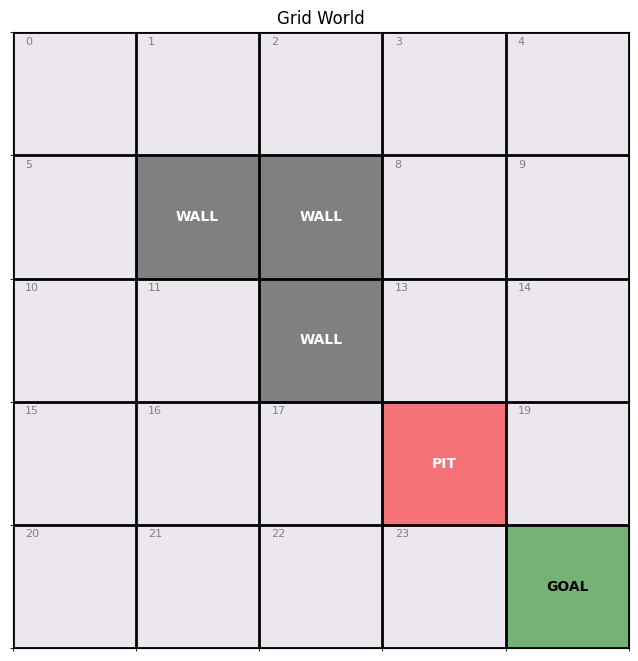

In [12]:
def plot_grid(values=None, policy=None, title="Grid World"):
    """
    Plots the 5x5 grid with environment features.
    
    Args:
        values (torch.Tensor or np.ndarray): Optional 1D array of state values to visualize as colors.
        policy (torch.Tensor or np.ndarray): Optional 2D array [N, A] or 1D array of best actions to show as arrows.
        title (str): Plot title.
    """
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Create the background grid
    grid = np.zeros((grid_size, grid_size))
    
    # If values are provided, use them for coloring
    if values is not None:
        if hasattr(values, "detach"): values = values.detach().cpu().numpy()
        grid = values.reshape(grid_size, grid_size)
    
    # Plot the grid
    im = ax.imshow(grid, cmap='viridis', origin='upper', alpha=0.3 if values is not None else 0.1)
    
    # Draw grid lines
    ax.set_xticks(np.arange(-0.5, grid_size, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, grid_size, 1), minor=True)
    ax.grid(which='minor', color='black', linestyle='-', linewidth=2)
    
    for s in range(N):
        r, c = state_to_pos(s)
        
        # Draw Environment Features
        if s == goal_grid:
            ax.add_patch(plt.Rectangle((c-0.5, r-0.5), 1, 1, color='green', alpha=0.5))
            ax.text(c, r, "GOAL", ha='center', va='center', fontweight='bold')
        elif s == pit_grid:
            ax.add_patch(plt.Rectangle((c-0.5, r-0.5), 1, 1, color='red', alpha=0.5))
            ax.text(c, r, "PIT", ha='center', va='center', fontweight='bold', color='white')
        elif s in wall_states:
            ax.add_patch(plt.Rectangle((c-0.5, r-0.5), 1, 1, color='gray'))
            ax.text(c, r, "WALL", ha='center', va='center', fontweight='bold', color='white')
        else:
            # Draw State Index
            ax.text(c-0.4, r-0.4, str(s), fontsize=8, color='gray')
            
            # Draw Value Text
            if values is not None:
                ax.text(c, r, f"{values[s]:.2f}", ha='center', va='center', fontsize=10)

        # Draw Policy Arrows
        if policy is not None:
            if hasattr(policy, "detach"): policy = policy.detach().cpu().numpy()
            
            # If policy is [N, A] (probs), get the argmax
            if len(policy.shape) == 2:
                best_action = np.argmax(policy[s], axis=-1)
            else:
                best_action = policy[s]
                
            if s not in terminal_states and s not in wall_states:
                # 0: up, 1: down, 2: left, 3: right
                dx, dy = 0, 0
                if best_action == 0: dy = -0.3
                elif best_action == 1: dy = 0.3
                elif best_action == 2: dx = -0.3
                elif best_action == 3: dx = 0.3
                
                ax.arrow(c, r, dx, dy, head_width=0.1, head_length=0.1, fc='black', ec='black')

    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.show()

# Usage Example:
plot_grid()


For this one wasnt necessary a grid search!

In [ ]:
solver_sbeed = MultiParametrizedSBEED(
    spec=mdp_spec,
    lambda_entropy=0.05,
    eta=0.1,
    lr_value=1e-2,
    lr_policy=1e-2,
    lr_rho=1e-2,
    tau=100000.0,
    max_buffer_size=12000,
    batch_size=256,
    rollout_length=3,

    fisher_damping=1e-3,
    cg_iters=10,
    cg_tol=1e-12,
    seed=SEED,
    device=DEVICE,
)

pi_sbeed = solver_sbeed.run(
    transition_fn=next_state,
    reward_fn=reward_fn,
    episodes=400,
    collect_per_episode=20,
    updates_per_episode=10,
    initial_collect_steps=512,
    start_state=x_0,
    epsilon=0.3,
    terminal_states={goal_grid, pit_grid},
    log_every=50,
)

episode=50/400 buffer=1512 objective=0.011907 primal_mse=0.012123 dual_mse=0.002159 theta_grad=1.792e-02 policy_grad=2.486e-02
episode=100/400 buffer=2512 objective=0.009633 primal_mse=0.010052 dual_mse=0.004190 theta_grad=1.239e-02 policy_grad=1.430e-02
episode=150/400 buffer=3512 objective=0.009864 primal_mse=0.010456 dual_mse=0.005930 theta_grad=1.393e-02 policy_grad=1.820e-02
episode=200/400 buffer=4512 objective=0.011345 primal_mse=0.011994 dual_mse=0.006491 theta_grad=1.887e-02 policy_grad=2.001e-02
episode=250/400 buffer=5512 objective=0.013168 primal_mse=0.013885 dual_mse=0.007173 theta_grad=1.307e-02 policy_grad=1.302e-02
episode=300/400 buffer=6512 objective=0.014417 primal_mse=0.015191 dual_mse=0.007737 theta_grad=1.542e-02 policy_grad=2.372e-02
episode=350/400 buffer=7512 objective=0.014718 primal_mse=0.015497 dual_mse=0.007792 theta_grad=2.451e-02 policy_grad=1.859e-02
episode=400/400 buffer=8512 objective=0.015106 primal_mse=0.015949 dual_mse=0.008437 theta_grad=1.674e-02

In [16]:
evaluator = SBEEDEvaluator(
    solver_sbeed,
    next_state_fn=next_state,
    reward_fn=reward_fn,
)
evaluator.print_policy()


========== SBEED POLICY ==========

State 0: pi(0|0)=0.094  pi(1|0)=0.771  pi(2|0)=0.095  pi(3|0)=0.040  --> best action: 1
State 1: pi(0|1)=0.129  pi(1|1)=0.135  pi(2|1)=0.278  pi(3|1)=0.458  --> best action: 3
State 2: pi(0|2)=0.110  pi(1|2)=0.107  pi(2|2)=0.031  pi(3|2)=0.752  --> best action: 3
State 3: pi(0|3)=0.091  pi(1|3)=0.586  pi(2|3)=0.013  pi(3|3)=0.310  --> best action: 1
State 4: pi(0|4)=0.095  pi(1|4)=0.821  pi(2|4)=0.019  pi(3|4)=0.064  --> best action: 1
State 5: pi(0|5)=0.014  pi(1|5)=0.807  pi(2|5)=0.090  pi(3|5)=0.089  --> best action: 1
State 6: pi(0|6)=0.250  pi(1|6)=0.250  pi(2|6)=0.250  pi(3|6)=0.250  --> best action: 0
State 7: pi(0|7)=0.250  pi(1|7)=0.250  pi(2|7)=0.250  pi(3|7)=0.250  --> best action: 0
State 8: pi(0|8)=0.008  pi(1|8)=0.446  pi(2|8)=0.064  pi(3|8)=0.482  --> best action: 3
State 9: pi(0|9)=0.003  pi(1|9)=0.921  pi(2|9)=0.006  pi(3|9)=0.070  --> best action: 1
State 10: pi(0|10)=0.011  pi(1|10)=0.477  pi(2|10)=0.062  pi(3|10)=0.450  --> best 

## Stochastic

We needed a small grid search:

In [14]:
from pathlib import Path
import csv, ast, json

RESULT_CSV = Path("/d/hpc/home/md72357/FOGAS/data/results/sbeed/sbeed_tabular_stochastic_grid_search.csv")

def to_num(x):
    if x is None or x == "":
        return x
    if isinstance(x, list):
        return x
    try:
        return float(x)
    except (ValueError, TypeError):
        return x

def to_bool(x):
    return str(x).lower() in {"true", "1", "yes"}

rows = []
with RESULT_CSV.open(newline="") as f:
    for r in csv.DictReader(f):
        # DictReader uses key None for extra columns in malformed/appended rows.
        r = {k: to_num(v) for k, v in r.items() if k is not None}
        r["ok"] = to_bool(r.get("ok"))
        rows.append(r)

valid = [r for r in rows if r["ok"]]
valid = sorted(valid, key=lambda r: r.get("score", float("-inf")), reverse=True)

cols = [
    "run_id", "score", "eval_return_mean", "eval_return_std",
    "eval_success_rate", "eval_length_mean",
    "rollout_length", "lambda_entropy", "eta",
    "lr_value", "lr_rho", "lr_policy",
    "fisher_damping", "batch_size", "epsilon",
    "episodes", "collect_per_episode", "updates_per_episode",
    "initial_collect_steps", "max_buffer_size",
]
cols = [c for c in cols if valid and c in valid[0]]

print(f"Using: {RESULT_CSV}")
print(f"Loaded {len(rows)} runs, {len(valid)} successful.")

try:
    import pandas as pd
    display(pd.DataFrame(valid[:10])[cols])
except Exception:
    for i, r in enumerate(valid[:10], 1):
        print(f"#{i:02d}", {c: r.get(c) for c in cols})

best = valid[0]

print("\nBEST CONFIG")
print(json.dumps({c: best.get(c) for c in cols}, indent=2))

actions = ast.literal_eval(best["best_actions"])
probs = ast.literal_eval(best["best_probs"])

arrow = {0: "^", 1: "v", 2: "<", 3: ">"}
walls = {6, 7, 12}
goal = 24
pit = 18
grid_size = 5

print("\nBEST GREEDY POLICY")
for r in range(grid_size):
    cells = []
    for c in range(grid_size):
        s = r * grid_size + c
        if s in walls:
            cells.append(" X ")
        elif s == goal:
            cells.append(" G ")
        elif s == pit:
            cells.append(" P ")
        else:
            cells.append(f" {arrow[int(actions[s])]} ")
    print("".join(cells))

print("\nBEST ACTION PROBABILITIES")
for r in range(grid_size):
    print(" ".join(f"{probs[r * grid_size + c]:.2f}" for c in range(grid_size)))

Using: /d/hpc/home/md72357/FOGAS/data/results/sbeed/sbeed_tabular_stochastic_grid_search.csv
Loaded 61 runs, 61 successful.


,run_id,score,eval_return_mean,eval_return_std,eval_success_rate,eval_length_mean,rollout_length,lambda_entropy,eta,lr_value,lr_rho,lr_policy,fisher_damping,batch_size,epsilon,episodes,collect_per_episode,updates_per_episode,initial_collect_steps,max_buffer_size
0,22.0,-0.255721,-0.203133,0.210198,0.963333,9.513333,2.0,0.05,0.20,0.003,0.003,0.003,0.0010,1024.0,0.2,800.0,25.0,15.0,2000.0,12000.0
1,19.0,-0.258333,-0.207962,0.201364,0.963333,9.593333,3.0,0.08,0.20,0.010,0.003,0.010,0.0100,,0.4,500.0,20.0,10.0,1024.0,12000.0
2,15.0,-0.270055,-0.215679,0.217342,0.960000,9.786667,2.0,0.05,0.00,0.010,0.010,0.010,0.0100,512.0,0.4,500.0,20.0,10.0,1024.0,12000.0
3,15.0,-0.270055,-0.215679,0.217342,0.960000,9.786667,2.0,0.05,0.00,0.010,0.010,0.010,0.0100,512.0,0.4,500.0,20.0,10.0,1024.0,12000.0
4,5.0,-0.272727,-0.220188,0.209976,0.960000,9.703333,3.0,0.05,0.05,0.010,0.003,0.003,0.0100,1024.0,0.3,500.0,20.0,10.0,1024.0,12000.0
5,5.0,-0.272727,-0.220188,0.209976,0.960000,9.703333,3.0,0.05,0.05,0.010,0.003,0.003,0.0100,1024.0,0.3,500.0,20.0,10.0,1024.0,12000.0
6,16.0,-0.280675,-0.224064,0.226003,0.953333,9.760000,1.0,0.01,0.10,0.010,0.030,0.010,0.0001,512.0,0.3,500.0,20.0,10.0,1024.0,12000.0
7,16.0,-0.280675,-0.224064,0.226003,0.953333,9.760000,1.0,0.01,0.10,0.010,0.030,0.010,0.0001,512.0,0.3,500.0,20.0,10.0,1024.0,12000.0
8,40.0,-0.287487,-0.230091,0.229364,0.946667,9.696667,3.0,0.05,0.05,0.010,0.003,0.003,0.0100,1024.0,0.3,800.0,25.0,15.0,2000.0,12000.0
9,26.0,-0.287713,-0.229605,0.231990,0.943333,9.656667,1.0,0.02,0.00,0.010,0.010,0.030,0.0010,256.0,0.4,500.0,20.0,10.0,1024.0,12000.0



BEST CONFIG
{
  "run_id": 22.0,
  "score": -0.25572074717478144,
  "eval_return_mean": -0.20313269480736373,
  "eval_return_std": 0.21019804092016856,
  "eval_success_rate": 0.9633333333333334,
  "eval_length_mean": 9.513333333333334,
  "rollout_length": 2.0,
  "lambda_entropy": 0.05,
  "eta": 0.2,
  "lr_value": 0.003,
  "lr_rho": 0.003,
  "lr_policy": 0.003,
  "fisher_damping": 0.001,
  "batch_size": 1024.0,
  "epsilon": 0.2,
  "episodes": 800.0,
  "collect_per_episode": 25.0,
  "updates_per_episode": 15.0,
  "initial_collect_steps": 2000.0,
  "max_buffer_size": 12000.0
}

BEST GREEDY POLICY
 >  >  >  v  v 
 v  X  X  >  v 
 v  v  X  >  v 
 >  v  v  P  v 
 >  >  >  >  G 

BEST ACTION PROBABILITIES
0.37 0.58 0.68 0.48 0.78
0.47 0.25 0.25 0.49 0.93
0.44 0.70 0.25 0.99 0.97
0.45 0.55 0.98 0.25 0.98
0.78 0.94 0.96 1.00 0.25


Now we know the best values. Rollout of k = 2 looks better!

In [15]:
def transition_probs(s, a):
    """
    Stochastic transition:
    80% intended action
    20% random action uniformly over all actions.
    """
    s = int(s)
    a = int(a)

    probs_by_state = {}

    for candidate_a in range(A):
        if candidate_a == a:
            prob = 0.8 + 0.2 / A
        else:
            prob = 0.2 / A

        sp = move_deterministic(s, candidate_a)
        probs_by_state[sp] = probs_by_state.get(sp, 0.0) + prob

    return list(probs_by_state.items())

def next_state(s, a):
    probs = transition_probs(s, a)

    next_states = [sp for sp, p in probs]
    probabilities = torch.tensor([p for sp, p in probs], dtype=torch.float)

    idx = torch.multinomial(probabilities, num_samples=1).item()

    return next_states[idx]

In [ ]:
solver_sbeed = MultiParametrizedSBEED(
    spec=mdp_spec,
    lambda_entropy=0.05,
    eta=0.2,
    lr_value=0.003,
    lr_policy=0.003,
    lr_rho=0.003,

    tau=100000.0,
    max_buffer_size=12000,
    batch_size=1024,
    rollout_length=2,
    fisher_damping=0.001,
    cg_iters=10,
    cg_tol=1e-12,

    seed=SEED,
    device=DEVICE,
)

pi_sbeed = solver_sbeed.run(
    transition_fn=next_state,
    reward_fn=reward_fn,
    episodes=800,
    collect_per_episode=25,
    updates_per_episode=15,
    initial_collect_steps=2000,
    start_state=x_0,
    epsilon=0.2,
    terminal_states={goal_grid, pit_grid},
    log_every=50,
)

episode=50/800 buffer=3250 objective=0.010341 primal_mse=0.011385 dual_mse=0.005218 theta_grad=5.605e-03 policy_grad=7.228e-03
episode=100/800 buffer=4500 objective=0.010046 primal_mse=0.011226 dual_mse=0.005898 theta_grad=6.115e-03 policy_grad=9.233e-03
episode=150/800 buffer=5750 objective=0.010604 primal_mse=0.012141 dual_mse=0.007681 theta_grad=6.785e-03 policy_grad=6.863e-03
episode=200/800 buffer=7000 objective=0.011125 primal_mse=0.012985 dual_mse=0.009301 theta_grad=6.342e-03 policy_grad=7.173e-03
episode=250/800 buffer=8250 objective=0.011341 primal_mse=0.013386 dual_mse=0.010222 theta_grad=6.627e-03 policy_grad=7.518e-03
episode=300/800 buffer=9500 objective=0.012549 primal_mse=0.014937 dual_mse=0.011938 theta_grad=6.635e-03 policy_grad=6.918e-03
episode=350/800 buffer=10750 objective=0.012963 primal_mse=0.015407 dual_mse=0.012223 theta_grad=5.902e-03 policy_grad=6.373e-03
episode=400/800 buffer=12000 objective=0.013957 primal_mse=0.016765 dual_mse=0.014041 theta_grad=6.798e-

In [17]:
evaluator = SBEEDEvaluator(
    solver_sbeed,
    next_state_fn=next_state,
    reward_fn=reward_fn,
)
evaluator.print_policy()


========== SBEED POLICY ==========

State 0: pi(0|0)=0.188  pi(1|0)=0.344  pi(2|0)=0.158  pi(3|0)=0.311  --> best action: 1
State 1: pi(0|1)=0.179  pi(1|1)=0.180  pi(2|1)=0.097  pi(3|1)=0.545  --> best action: 3
State 2: pi(0|2)=0.152  pi(1|2)=0.137  pi(2|2)=0.042  pi(3|2)=0.668  --> best action: 3
State 3: pi(0|3)=0.131  pi(1|3)=0.461  pi(2|3)=0.027  pi(3|3)=0.381  --> best action: 1
State 4: pi(0|4)=0.103  pi(1|4)=0.723  pi(2|4)=0.051  pi(3|4)=0.122  --> best action: 1
State 5: pi(0|5)=0.081  pi(1|5)=0.586  pi(2|5)=0.161  pi(3|5)=0.172  --> best action: 1
State 6: pi(0|6)=0.250  pi(1|6)=0.250  pi(2|6)=0.250  pi(3|6)=0.250  --> best action: 0
State 7: pi(0|7)=0.250  pi(1|7)=0.250  pi(2|7)=0.250  pi(3|7)=0.250  --> best action: 0
State 8: pi(0|8)=0.030  pi(1|8)=0.279  pi(2|8)=0.100  pi(3|8)=0.591  --> best action: 3
State 9: pi(0|9)=0.008  pi(1|9)=0.948  pi(2|9)=0.012  pi(3|9)=0.033  --> best action: 1
State 10: pi(0|10)=0.038  pi(1|10)=0.499  pi(2|10)=0.137  pi(3|10)=0.325  --> best 